In [62]:
import pandas as pd
from datetime import datetime
import re
import matplotlib.pyplot as plt

In [63]:
hs = pd.read_csv("/Users/lyna/Documents/M1/S2/airport_project/data/historic_schedule.csv")
fs = pd.read_csv("/Users/lyna/Documents/M1/S2/airport_project/data/future_schedule.csv")
ds_km = pd.read_csv("/Users/lyna/Documents/M1/S2/airport_project/data/distance_km_EDI.csv")

In [64]:
# créer le dictionnaire airport -> distance
dist_map = dict(zip(ds_km["airport"], ds_km["distance_km"]))

# ajouter la colonne dans hs
hs["distance_km"] = hs["Origin / Destination"].map(dist_map)
hs

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival_Departure,Aircraft Type,Airline,Origin / Destination,distance_km
0,6/1/23 0:00,Commercial,2719556,2655707,A,C,FR,VLC,1843
1,6/1/23 0:05,Commercial,2719557,2655734,A,C,FR,KUN,1729
2,6/1/23 0:15,Commercial,2655685,2719558,A,C,FR,OPO,1680
3,6/1/23 0:30,Commercial,2655686,2655729,A,C,U2,DLM,3221
4,6/1/23 1:10,Cargo,2742844,2655967,A,C,NPT,STN,511
...,...,...,...,...,...,...,...,...,...
92937,8/31/25 23:15,Commercial,3169185,3169243,A,C,BA,LHR,534
92938,8/31/25 23:20,Commercial,3169186,3262831,A,C,FR,BCN,1677
92939,8/31/25 23:35,Commercial,3197766,3262830,A,C,RK,STN,511
92940,8/31/25 23:40,Commercial,3203517,3196513,A,C,FR,ACE,3108


In [65]:
print(hs.info())
print(fs.info())

<class 'pandas.DataFrame'>
RangeIndex: 92942 entries, 0 to 92941
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Date and Time         92942 non-null  str  
 1   Passenger/Cargo       92942 non-null  str  
 2   Flight ID             92942 non-null  int64
 3   Turnaround Flight ID  92942 non-null  int64
 4   Arrival_Departure     92942 non-null  str  
 5   Aircraft Type         92942 non-null  str  
 6   Airline               92942 non-null  str  
 7   Origin / Destination  92942 non-null  str  
 8   distance_km           92942 non-null  int64
dtypes: int64(3), str(6)
memory usage: 6.4 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 35310 entries, 0 to 35309
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Date and Time         35310 non-null  str  
 1   Passenger/Cargo       35310 non-null  str  
 2   Flight ID      

In [66]:
print(fs.isnull().sum())
print(hs.isnull().sum())

Date and Time           0
Passenger/Cargo         0
Flight ID               0
Arrival / Departure     0
Aircraft Type           0
Airline                 0
Origin / Destination    0
dtype: int64
Date and Time           0
Passenger/Cargo         0
Flight ID               0
Turnaround Flight ID    0
Arrival_Departure       0
Aircraft Type           0
Airline                 0
Origin / Destination    0
distance_km             0
dtype: int64


In [67]:
def date_time(df) :
    df["Date and Time"] = pd.to_datetime(df["Date and Time"], format="%m/%d/%y %H:%M")
    df["Date"] = df["Date and Time"].dt.date
    df["Time"] = df["Date and Time"].dt.time

date_time(hs)
date_time(fs)

In [68]:
def get_season(date):
    year = date.year
    # Dates limites
    spring = datetime(year, 3, 21)
    summer = datetime(year, 6, 21)
    fall   = datetime(year, 9, 23)
    winter = datetime(year, 12, 21)

    if spring <= date < summer:
        return "Spring"
    elif summer <= date < fall:
        return "Summer"
    elif fall <= date < winter:
        return "Fall"
    else:
        # Winter chevauche deux années : déc à mars
        if date >= winter:
            return "Winter"
        else:
            return "Winter"

hs["Season"] = hs["Date and Time"].apply(get_season)
fs["Season"] = fs["Date and Time"].apply(get_season)

#print(hs[["Date and Time", "Season"]])
hs['Season'].value_counts()

Season
Summer    72667
Spring    20275
Name: count, dtype: int64

In [69]:
def flights_nb(df) :
    flights_by_season = df.groupby("Season").size()/len(df)*100
    print(flights_by_season)
    print()
flights_nb(hs)

Season
Spring    21.81468
Summer    78.18532
dtype: float64



In [70]:
def valuecounts(series):
    counts = series.value_counts()
    print(counts)
valuecounts(hs['Aircraft Type'])
valuecounts(hs['Airline'])
valuecounts(hs['Origin / Destination'])


Aircraft Type
C    82957
D     4117
B     3883
E     1975
A       10
Name: count, dtype: int64
Airline
U2     19233
FR     19065
BA      8798
LM      7157
LS      6080
       ...  
BRO        2
EA         1
WX         1
ARN        1
S6         1
Name: count, Length: 81, dtype: int64
Origin / Destination
LHR    5235
DUB    5175
AMS    3403
STN    3391
CDG    2785
       ... 
JED       1
RDU       1
XFW       1
BGR       1
VIT       1
Name: count, Length: 222, dtype: int64


In [71]:
hsa = hs[hs['Arrival_Departure'] == 'A']
hsd = hs[hs['Arrival_Departure'] == 'D']
hsd.Arrival_Departure.value_counts()

Arrival_Departure
D    46480
Name: count, dtype: int64

In [72]:
hs_sorted = hs.sort_values(by='distance_km', ascending=False)
hs_sorted.head()

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival_Departure,Aircraft Type,Airline,Origin / Destination,distance_km,Date,Time,Season
49346,2024-08-02 10:20:00,Commercial,3073639,3073661,A,E,QR,LAX,8312,2024-08-02,10:20:00,Summer
75152,2025-07-13 12:00:00,Commercial,3246320,3246319,D,E,HU,PEK,7957,2025-07-13,12:00:00,Summer
43709,2024-07-17 12:00:00,Commercial,3008879,3008878,D,E,HU,PEK,7957,2024-07-17,12:00:00,Summer
58425,2024-08-28 12:00:00,Commercial,3008963,3008962,D,E,HU,PEK,7957,2024-08-28,12:00:00,Summer
49993,2024-08-04 06:30:00,Commercial,3008916,3008917,A,E,HU,PEK,7957,2024-08-04,06:30:00,Summer


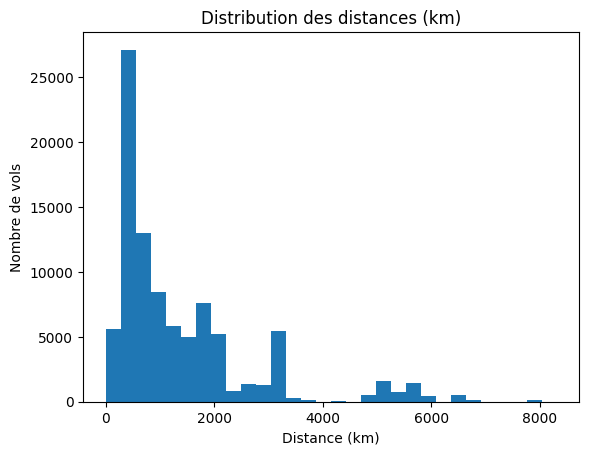

In [73]:
plt.figure()

plt.hist(hs["distance_km"].dropna(), bins=30)

plt.title("Distribution des distances (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Nombre de vols")

plt.show()

## Traitement uniquement des vols commerciaux et de la compagnie aérienne U2 pour commencer

In [74]:
u2 = hs[hs['Airline'] == 'U2']
u2['Aircraft Type'].value_counts()
#que des vols commerciaux pour U2

Aircraft Type
C    19233
Name: count, dtype: int64

In [75]:
u2d = u2[u2['Arrival_Departure'] == 'D']
u2a = u2[u2['Arrival_Departure'] == 'A']

In [76]:
u2a.head()

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival_Departure,Aircraft Type,Airline,Origin / Destination,distance_km,Date,Time,Season
3,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM,3221,2023-06-01,00:30:00,Spring
6,2023-06-01 01:20:00,Commercial,2749224,2655728,A,C,U2,ATH,2852,2023-06-01,01:20:00,Spring
7,2023-06-01 01:25:00,Commercial,2655690,2655715,A,C,U2,HER,3151,2023-06-01,01:25:00,Spring
61,2023-06-01 08:20:00,Commercial,2655743,2655754,A,C,U2,BRS,510,2023-06-01,08:20:00,Spring
73,2023-06-01 09:20:00,Commercial,2655761,2655768,A,C,U2,BFS,231,2023-06-01,09:20:00,Spring


In [77]:
u2_m = u2a.merge(
    u2d,
    left_on='Turnaround Flight ID',
    right_on='Flight ID',
    how='left',
    suffixes=('_A', '_D')
)
u2_m.head()

,Date and Time_A,Passenger/Cargo_A,Flight ID_A,Turnaround Flight ID_A,Arrival_Departure_A,Aircraft Type_A,Airline_A,Origin / Destination_A,distance_km_A,Date_A,...,Flight ID_D,Turnaround Flight ID_D,Arrival_Departure_D,Aircraft Type_D,Airline_D,Origin / Destination_D,distance_km_D,Date_D,Time_D,Season_D
0,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM,3221,2023-06-01,...,2655729.0,2655686.0,D,C,U2,NCE,1561.0,2023-06-01,07:00:00,Spring
1,2023-06-01 01:20:00,Commercial,2749224,2655728,A,C,U2,ATH,2852,2023-06-01,...,2655728.0,2749224.0,D,C,U2,BFS,231.0,2023-06-01,07:00:00,Spring
2,2023-06-01 01:25:00,Commercial,2655690,2655715,A,C,U2,HER,3151,2023-06-01,...,2655715.0,2655690.0,D,C,U2,BHX,403.0,2023-06-01,06:35:00,Spring
3,2023-06-01 08:20:00,Commercial,2655743,2655754,A,C,U2,BRS,510,2023-06-01,...,2655754.0,2655743.0,D,C,U2,BRS,510.0,2023-06-01,08:50:00,Spring
4,2023-06-01 09:20:00,Commercial,2655761,2655768,A,C,U2,BFS,231,2023-06-01,...,2655768.0,2655761.0,D,C,U2,BER,1169.0,2023-06-01,09:50:00,Spring


In [78]:
mask = u2_m['Date_A'] != u2_m['Date_D']
u2_m[mask]

,Date and Time_A,Passenger/Cargo_A,Flight ID_A,Turnaround Flight ID_A,Arrival_Departure_A,Aircraft Type_A,Airline_A,Origin / Destination_A,distance_km_A,Date_A,...,Flight ID_D,Turnaround Flight ID_D,Arrival_Departure_D,Aircraft Type_D,Airline_D,Origin / Destination_D,distance_km_D,Date_D,Time_D,Season_D
24,2023-06-01 21:55:00,Commercial,2655970,2656020,A,C,U2,BRS,510,2023-06-01,...,2656020.0,2655970.0,D,C,U2,LTN,495.0,2023-06-02,06:20:00,Spring
25,2023-06-01 22:05:00,Commercial,2655974,2656032,A,C,U2,CDG,870,2023-06-01,...,2656032.0,2655974.0,D,C,U2,BHX,403.0,2023-06-02,07:00:00,Spring
26,2023-06-01 22:15:00,Commercial,2655976,2656016,A,C,U2,STN,511,2023-06-01,...,2656016.0,2655976.0,D,C,U2,MAD,1721.0,2023-06-02,06:05:00,Spring
27,2023-06-01 22:25:00,Commercial,2655977,2656034,A,C,U2,BHX,403,2023-06-01,...,2656034.0,2655977.0,D,C,U2,CPH,1004.0,2023-06-02,07:00:00,Spring
28,2023-06-01 23:15:00,Commercial,2655984,2656013,A,C,U2,MUC,1333,2023-06-01,...,2656013.0,2655984.0,D,C,U2,LGW,574.0,2023-06-02,06:00:00,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9588,2025-08-30 22:30:00,Commercial,3168823,3168890,A,C,U2,BRS,510,2025-08-30,...,3168890.0,3168823.0,D,C,U2,BFS,231.0,2025-08-31,07:00:00,Summer
9589,2025-08-30 22:40:00,Commercial,3263873,3168891,A,C,U2,CDG,870,2025-08-30,...,3168891.0,3263873.0,D,C,U2,LGW,574.0,2025-08-31,07:00:00,Summer
9590,2025-08-30 23:05:00,Commercial,3168831,3168896,A,C,U2,KRK,1676,2025-08-30,...,3168896.0,3168831.0,D,C,U2,STN,511.0,2025-08-31,07:15:00,Summer
9591,2025-08-30 23:55:00,Commercial,3168843,3168873,A,C,U2,NCE,1561,2025-08-30,...,3168873.0,3168843.0,D,C,U2,NCE,1561.0,2025-08-31,06:10:00,Summer


In [79]:
u2_m['Date and Time_A'] = pd.to_datetime(u2_m['Date and Time_A'])
u2_m['Date and Time_D'] = pd.to_datetime(u2_m['Date and Time_D'])
u2_m['ground_time'] = u2_m['Date and Time_D'] - u2_m['Date and Time_A']
u2_m['ground_time_min'] = u2_m['ground_time'].dt.total_seconds() / 60
u2_m.head()

,Date and Time_A,Passenger/Cargo_A,Flight ID_A,Turnaround Flight ID_A,Arrival_Departure_A,Aircraft Type_A,Airline_A,Origin / Destination_A,distance_km_A,Date_A,...,Arrival_Departure_D,Aircraft Type_D,Airline_D,Origin / Destination_D,distance_km_D,Date_D,Time_D,Season_D,ground_time,ground_time_min
0,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM,3221,2023-06-01,...,D,C,U2,NCE,1561.0,2023-06-01,07:00:00,Spring,0 days 06:30:00,390.0
1,2023-06-01 01:20:00,Commercial,2749224,2655728,A,C,U2,ATH,2852,2023-06-01,...,D,C,U2,BFS,231.0,2023-06-01,07:00:00,Spring,0 days 05:40:00,340.0
2,2023-06-01 01:25:00,Commercial,2655690,2655715,A,C,U2,HER,3151,2023-06-01,...,D,C,U2,BHX,403.0,2023-06-01,06:35:00,Spring,0 days 05:10:00,310.0
3,2023-06-01 08:20:00,Commercial,2655743,2655754,A,C,U2,BRS,510,2023-06-01,...,D,C,U2,BRS,510.0,2023-06-01,08:50:00,Spring,0 days 00:30:00,30.0
4,2023-06-01 09:20:00,Commercial,2655761,2655768,A,C,U2,BFS,231,2023-06-01,...,D,C,U2,BER,1169.0,2023-06-01,09:50:00,Spring,0 days 00:30:00,30.0


In [80]:
bins = [0, 30, 60, 120, 240, 1440]
labels = ["<30min", "30-60min", "1-2h", "2-4h", "4h+"]

u2_m["ground_time_cat"] = pd.cut(
    u2_m["ground_time_min"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
u2_m.groupby("ground_time_cat")["distance_km_D"].mean()

ground_time_cat
<30min       566.860200
30-60min    1189.972989
1-2h        1657.827778
2-4h        1523.252033
4h+         1094.131590
Name: distance_km_D, dtype: float64

In [87]:

bins = [0, 500, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
labels = ["0-500", "501-1000", "1001-2000", "2001-3000", "3001-4000",
          "4001-5000", "5001-6000", "6001-7000", "7001-8000", "8001-9000", "9001-10000"]

u2_m["km_cat"] = pd.cut(
    u2_m["distance_km_D"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
u2_m.groupby("km_cat")["ground_time_cat"].mean()

TypeError: category dtype does not support aggregation 'mean'